# Laboratorio 8 - Deep Learning

- Juan Solís - 23720
- Victor Pérez - 23731
- Diego Flores - 23714

## Implementación Mini GPT Semana 6

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, urllib.request
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Mini-GPT de la Semana 6 (adaptado a batches y a n_layers bloques)
def layer_norm(x, gamma, beta, eps=1e-5):
    # LN(x) = gamma * (x - media) / (std + eps) + beta
    mean = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1, keepdim=True, unbiased=False)

    return gamma * (x - mean) / (std + eps) + beta

def make_positional_encoding(max_len, d_model):
    # PE(t, 2i) = sin(t / 10000^(2i/d_model)),  PE(t, 2i+1) = cos(t / 10000^(2i/d_model))
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)

    return pe

# Bloque decoder: masked self-attention -> Add & Norm -> FFN -> Add & Norm
class GPTBlock(nn.Module):
    def __init__(self, d_model, d_ff, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x, causal):
        B, T, _ = x.shape
        Q = (x @ self.WQ).view(B, T, self.n_heads, self.d_k).transpose(1, 2) # (B, H, T, d_k)
        K = (x @ self.WK).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-1, -2) / math.sqrt(self.d_k) # QK^T / sqrt(d_k)
        scores = scores.masked_fill(causal[:T, :T], float('-inf')) # mascara causal
        attn_w = F.softmax(scores, dim=-1)
        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, self.d_model)

        return out @ self.WO

    def feed_forward(self, x):
        # FFN(x) = ReLU(x W1 + b1) W2 + b2
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, causal):
        x2 = layer_norm(x + self.masked_self_attention(x, causal), self.gamma1, self.beta1)
        return layer_norm(x2 + self.feed_forward(x2), self.gamma2, self.beta2)

# Transformer decoder-only: E[idxs] + PE -> n_layers bloques -> proyeccion al vocabulario
class MiniGPT(nn.Module):
    def __init__(self, V, d_model, d_ff, n_heads, n_layers, block_size):
        super().__init__()
        self.E = nn.Parameter(torch.randn(V, d_model))  # std 1 (como nn.Embedding) para que la PE no opaque al token
        self.blocks = nn.ModuleList([GPTBlock(d_model, d_ff, n_heads) for _ in range(n_layers)])
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.1)
        self.blm = nn.Parameter(torch.zeros(V))
        self.register_buffer('pe', make_positional_encoding(block_size, d_model))
        self.register_buffer('causal', torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())

    def forward(self, idxs):
        # idxs: (B, T) -> logits: (B, T, V)
        T = idxs.shape[1]
        x = self.E[idxs] + self.pe[:T]
        
        for block in self.blocks:
            x = block(x, self.causal)
        return x @ self.Wlm + self.blm

## Task 1

### Task 1.1

Se descarga `tiny_shakespeare`, se construye el vocabulario de caracteres con sus mappings carácter-índice y se codifica el texto, dividiéndolo en 90% entrenamiento y 10% validación sin alterar el orden. También se define la función `get_batch`, que genera secuencias de longitud `block_size` cuyo objetivo es la misma secuencia desplazada un paso hacia el futuro.

In [ ]:
# Hiperparametros
block_size = 128
d_model= 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10
d_ff = 4 * d_model

# Descarga del dataset
url='https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve( url, 'input.txt')
with open('input.txt', encoding='utf-8' ) as f:
    text = f.read()

# Vocabulario y mappings bidireccionales caracter indice
chars = sorted(set(text) )
V = len(chars )
stoi = { c: i for i, c in enumerate(chars)}
itos = { i: c for c, i in stoi.items()}
print(f'Tamano del vocabulario: {V}' )

# Codificacion del texto y division 90/10 respetando el orden
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f'Train: {len(train_data)} tokens | Val: {len(val_data)} tokens')

# Batches: y es x desplazada un paso hacia el futuro
def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'x: {tuple(xb.shape)} | y: {tuple(yb.shape)}')

Tamano del vocabulario: 65
Train: 1003854 tokens | Val: 111540 tokens
x: (64, 128) | y: (64, 128)


### Task 1.2

Se entrena el Mini-GPT sobre `tiny_shakespeare` con los hiperparámetros anteriores, registrando la pérdida de entrenamiento y validación en cada época para graficar sus curvas. Al final se calcula la perplejidad de validación como la exponencial de la cross-entropy promedio sobre todos los tokens del conjunto de validación.

Epoch  1: train_loss=2.9290 | val_loss=2.5622
Epoch  2: train_loss=2.4928 | val_loss=2.4531
Epoch  3: train_loss=2.3827 | val_loss=2.3475
Epoch  4: train_loss=2.2665 | val_loss=2.2415
Epoch  5: train_loss=2.1658 | val_loss=2.1679
Epoch  6: train_loss=2.0804 | val_loss=2.1113
Epoch  7: train_loss=2.0162 | val_loss=2.0657
Epoch  8: train_loss=1.9558 | val_loss=2.0312
Epoch  9: train_loss=1.9068 | val_loss=2.0041
Epoch 10: train_loss=1.8677 | val_loss=1.9672


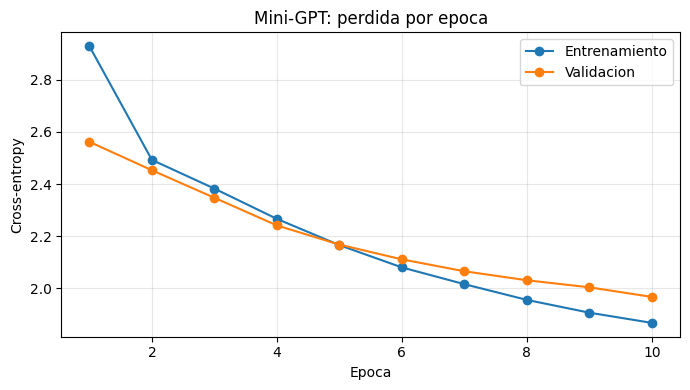

Perplejidad de validacion: 7.1508


In [3]:
model = MiniGPT(V, d_model, d_ff, n_heads, n_layers, block_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
steps_per_epoch = len(train_data) // (batch_size * block_size)  # ~una pasada por el set de entrenamiento

@torch.no_grad()
def evaluate(d):
    # Cross-entropy promedio (1/N) * sum L_t sobre todos los tokens de d
    n_blocks = (len(d) - 1) // block_size
    x = d[:n_blocks * block_size].view(n_blocks, block_size)
    y = d[1:n_blocks * block_size + 1].view(n_blocks, block_size)
    total, N = 0.0, 0
    for i in range(0, n_blocks, batch_size):
        xb, yb = x[i:i + batch_size].to(device), y[i:i + batch_size].to(device)
        logits = model(xb)
        total += F.cross_entropy(logits.view(-1, V), yb.view(-1), reduction='sum').item()
        N += yb.numel()
    return total / N

# Entrenamiento
train_losses, val_losses = [], []
for epoch in range(epochs):
    total = 0.0
    for _ in range(steps_per_epoch):
        xb, yb = get_batch('train')
        logits = model(xb)
        loss = F.cross_entropy(logits.view(-1, V), yb.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_losses.append(total / steps_per_epoch)
    val_losses.append(evaluate(val_data))
    print(f'Epoch {epoch + 1:2d}: train_loss={train_losses[-1]:.4f} | val_loss={val_losses[-1]:.4f}')

# Curvas de perdida por epoca
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, 'o-', label='Entrenamiento')
plt.plot(range(1, epochs + 1), val_losses, 'o-', label='Validacion')
plt.title('Mini-GPT: perdida por epoca'); plt.xlabel('Epoca'); plt.ylabel('Cross-entropy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# Perplejidad de validacion = exp((1/N) * sum L_t)
val_ppl = math.exp(val_losses[-1])
print(f'Perplejidad de validacion: {val_ppl:.4f}')

### Task 1.3

Se implementan desde cero las tres estrategias de muestreo (greedy, top-k con temperatura y top-p con temperatura), cada una recibe los logits crudos del modelo y retorna el índice del siguiente token.

In [ ]:
# Muestreo greedy: argmax de los logits, sin aleatoriedad
def greedy_sampling(logits):
    return torch.argmax(logits).item()

# Muestreo top-k con temperatura
def top_k_sampling(logits, k, tau):
    logits = logits / tau # z / tau
    vals, idxs = torch.topk(logits, k) # k logits mas altos
    filtered = torch.full_like(logits, float('-inf')) # -inf al resto
    filtered[idxs] = vals
    probs = F.softmax(filtered, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

# Muestreo top-p (nucleus) con temperatura
def top_p_sampling(logits, p, tau):
    probs = F.softmax(logits / tau, dim=-1) # softmax(z / tau)
    sorted_probs, sorted_idxs = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    keep = (cum_probs - sorted_probs) < p # tokens hasta superar p
    kept_probs = sorted_probs[keep] / sorted_probs[keep].sum() # renormalizar
    choice = torch.multinomial(kept_probs, num_samples=1).item()
    return sorted_idxs[keep][choice].item()